# Gán nhãn

In [25]:
import pandas as pd
df = pd.read_csv("data.csv")
df

,text
0,Từ học bổng thay đổi cuộc đời đến lớp học tiến...
1,Trường ĐH Tôn Đức Thắng công bố 4 nhóm nghiên ...
2,Đề thi thử tốt nghiệp THPT môn Toán của thành ...
3,Sở Giáo dục TPHCM lên tiếng việc 47.000 giáo v...
4,Người mẹ trăn trở trước giờ ghi 'đơn xanh' ngu...
...,...
2006,Khoảnh khắc đàn voi xếp vòng tròn bảo vệ con t...
2007,"Biết bạn gái chống chọi bệnh tật suốt 20 năm, ..."
2008,Bí mật phong thủy trong biệt phủ được xây suốt...
2009,"Vườn hồng rực rỡ, rau trái sum sê trên sân thư..."


In [2]:
# Re-run the full pipeline to read ./data.csv, extract POS/NEG terms present,
# and label with Snorkel LabelModel (fallback to rule-based if Snorkel unavailable).
import pandas as pd, re, json, unicodedata
import numpy as np
from collections import Counter

def strip_accents(s: str) -> str:
    if not isinstance(s, str): 
        return ""
    s = s.replace("đ","d").replace("Đ","D")
    return "".join(ch for ch in unicodedata.normalize("NFKD", s) if not unicodedata.combining(ch))

def norm(s: str) -> str:
    s = strip_accents(s.lower().strip())
    s = re.sub(r"\s+"," ", s)
    return s

def contains_any(text: str, terms) -> bool:
    t = norm(text)
    for w in terms:
        if re.search(rf"\b{re.escape(norm(w))}\b", t):
            return True
    return False

def has_negation_near(text: str, terms, window: int = 4) -> bool:
    NEGATIONS = {"khong","ko","k","kg","chua","chua tung","chua he","chua duoc","chang"}
    toks = norm(text).split()
    if not toks: return False
    txt = " ".join(toks)
    for w in terms:
        pat = re.compile(rf"\b{re.escape(norm(w))}\b")
        for m in pat.finditer(txt):
            start_tok = len(txt[:m.start()].split())
            end_tok   = start_tok + len(norm(w).split()) - 1
            left = max(0, start_tok - window)
            right = min(len(toks)-1, end_tok + window)
            window_text = " ".join(toks[left:right+1])
            if any(re.search(rf"\b{re.escape(neg)}\b", window_text) for neg in NEGATIONS):
                return True
    return False

# Load CSV
csv_path = "./data.csv"
df = pd.read_csv(csv_path)

# Detect text column
text_col = None
for c in ["text", "title", "headline", "content"]:
    if c in df.columns:
        text_col = c
        break
if text_col is None:
    for c in df.columns:
        if df[c].dtype == "object":
            text_col = c
            break
if text_col is None:
    raise ValueError("Không thấy cột văn bản ('text'/'title'/'headline'/'content').")

df = df[df[text_col].notna()].copy()
df["_text_norm"] = df[text_col].apply(norm)

# Seed lexicons
SEED_POS = {
    "tich cuc","kha quan","dang mung","thuan loi","hieu qua","an toan","thanh cong",
    "ky luc","tang truong","phuc hoi","cai thien","vuot muc tieu","nang cap","phat trien",
    "vinh danh","khen thuong","dat giai","giai thuong","xep hang cao","tien phong",
    "mo rong","giam phi","giam gia","uu dai","mien phi","ho tro","tro cap","an sinh",
    "ban giao","dua vao van hanh","ky ket","hop tac","hop dong lon","goi von","ipo thanh cong",
    "loi nhuan ky luc","doanh thu ky luc","khoi sac","phuc hoi manh","trung thau","giai ngan",
    "khoi cong","khoi dong","khai truong","khanh thanh","ra mat","cong bo","phe duyet","thanh lap",
    "mo ban","mo cua tro lai","thu nghiem thanh cong","de an duoc thong qua","trien khai",
    "tiep suc","hoc bong","nhom nghien cuu manh","doi moi sang tao","chuyen doi so",
    "dat chuan","duoc cong nhan","do dau","dau bang","tang chi tieu tuyen sinh","dat chuan kiem dinh",
    "phau thuat thanh cong","ghep tang thanh cong","khoi benh","xuat vien","kiem soat dich",
    "xoa ngheo","giam ngheo","tang muc song","tang phuc loi","tang luong","tang phu cap",
    "bao hiem chi tra","cuu tro","cuu song","giai cuu",
    "gianh chien thang","chien thang","vo dich","len ngoi","pha ky luc","vao chung ket",
    "thang dam","thang sat nut","thang nhe","thang quan",
    "dong khach","chay ve","doat giai","giai thuong quoc te","ra mat phim","ra mat mv",
    "mo ban du an","ban giao nha","ban giao so","giam lai suat","phe duyet quy hoach",
    "ban cap nhat","phat song","phu song","ra mat ung dung"
}

SEED_NEG = {
    "chay","chay lon","no","sap","sat lo","ngap","lu lut","bao","dong dat","han han","su co","thiet hai",
    "khung hoang","bat on","bat thuong","cap bach","dot bien xau",
    "lua dao","gia mao","hang gia","thuoc gia","sua gia","to cao","khoi to","bat tam giam",
    "tac trach","tieu cuc","tham nhung","hoi lo","vi pham","sai pham","xu phat","truy to","xet xu",
    "khieu nai","kien","don kien","tranh chap","be boi","truy na","an mang",
    "that nghiep","giam luong","thua lo","no xau","lam phat","roi loan","dinh tre","cham tien do",
    "qua tai","giam manh","giam sau","suy giam","suy thoai","khong dat","tut doc",
    "dich benh","bung phat","o dich","benh hiem ngheo","ngo doc","tu vong","chet","sot xuat huyet",
    "sap mang","sap he thong","lo hong","lo hong bao mat","ro ri du lieu","tan cong mang","ransomware","bi hack",
    "tin gia","mao danh","lua dao truc tuyen","spam",
    "trieu hoi xe","tai nan","lat xe","dieu tra nguyen nhan",
    "chat chem","ket xe","qua tai khach","tai nan du lich",
    "lo de","gian lan thi cu","bao luc hoc duong",
    "thua dam","bi loai","dut mach thang","chan thuong nang",
    "thoi gia","sot dat","bong bong","du an ma","ket phap ly","cham cap so","cuong che","tranh chap dat dai",
    "lum xum","be boi","bi chi trich","tay chay"
}

NEU_HINTS = {
    "cap nhat","thong bao","huong dan","bao cao","thong ke","so lieu",
    "lich thi","de thi","dap an","tuyen sinh","ke hoach","lich trinh","quy dinh",
    "danh sach","top","xep hang","ai la","co phai","vi sao","bao nhieu","la gi","hoi dap"
}

# Which terms appear in data?
def find_terms_in_corpus(texts_norm, term_set):
    found = Counter()
    for t in texts_norm:
        for w in term_set:
            if re.search(rf"\b{re.escape(norm(w))}\b", t):
                found[w] += 1
    return found

pos_found = find_terms_in_corpus(df["_text_norm"], SEED_POS)
neg_found = find_terms_in_corpus(df["_text_norm"], SEED_NEG)

pos_terms_sorted = [k for k,_ in pos_found.most_common()]
neg_terms_sorted = [k for k,_ in neg_found.most_common()]

with open("./pos_terms_found.json","w",encoding="utf-8") as f:
    json.dump({"pos_terms": pos_terms_sorted, "counts": pos_found}, f, ensure_ascii=False, indent=2)
with open("./neg_terms_found.json","w",encoding="utf-8") as f:
    json.dump({"neg_terms": neg_terms_sorted, "counts": neg_found}, f, ensure_ascii=False, indent=2)

# Try Snorkel
SNORKEL_OK = True
try:
    from snorkel.labeling.model.label_model import LabelModel
    from snorkel.labeling.apply.pandas import PandasLFApplier
    from snorkel.labeling import labeling_function
except Exception:
    try:
        from snorkel.labeling import LabelModel, PandasLFApplier, labeling_function
    except Exception:
        try:
            from snorkel.labeling.model import LabelModel
            from snorkel.labeling.apply.pandas import PandasLFApplier
            from snorkel.labeling import labeling_function
        except Exception as e:
            SNORKEL_OK = False
            snorkel_err = str(e)

ABSTAIN, POS, NEG, NEU = -1, 0, 1, 2
POS_TERMS = set(pos_terms_sorted) if pos_terms_sorted else SEED_POS
NEG_TERMS = set(neg_terms_sorted) if neg_terms_sorted else SEED_NEG

def lf_neu_hint_func(text: str) -> bool:
    return contains_any(text, NEU_HINTS)

if SNORKEL_OK:
    @labeling_function()
    def lf_pos_kw(x):
        return POS if contains_any(x[text_col], POS_TERMS) else ABSTAIN

    @labeling_function()
    def lf_neg_kw(x):
        return NEG if contains_any(x[text_col], NEG_TERMS) else ABSTAIN

    @labeling_function()
    def lf_negation_flip_pos(x):
        return NEG if has_negation_near(x[text_col], POS_TERMS) else ABSTAIN

    @labeling_function()
    def lf_negation_flip_neg(x):
        return POS if has_negation_near(x[text_col], NEG_TERMS) else ABSTAIN

    @labeling_function()
    def lf_neu_fallback(x):
        return NEU if lf_neu_hint_func(x[text_col]) else ABSTAIN

    LFs = [lf_pos_kw, lf_neg_kw, lf_negation_flip_pos, lf_negation_flip_neg, lf_neu_fallback]

    applier = PandasLFApplier(lfs=LFs)
    L = applier.apply(df=df[[text_col]])

    label_model = LabelModel(cardinality=3, verbose=False)
    label_model.fit(L_train=L, n_epochs=500, log_freq=100, seed=7)

    probs = label_model.predict_proba(L)  # [POS, NEG, NEU]
    preds = label_model.predict(L)

    out = df.copy()
    out[["p_pos","p_neg","p_neu"]] = probs
    out["pred_label"] = np.where(preds==POS,"positive", np.where(preds==NEG,"negative","neutral"))
    out["confidence"] = out[["p_pos","p_neg","p_neu"]].max(axis=1)
    out_path = "./data_labeled_snorkel.csv"
    out.to_csv(out_path, index=False)
    snorkel_status = "Snorkel LabelModel: OK"
else:
    # Fallback: majority-like
    def score_rule(text: str):
        t = norm(text)
        pos = sum(1 for w in POS_TERMS if re.search(rf"\b{re.escape(norm(w))}\b", t))
        neg = sum(1 for w in NEG_TERMS if re.search(rf"\b{re.escape(norm(w))}\b", t))
        if has_negation_near(text, POS_TERMS): neg += 1
        if has_negation_near(text, NEG_TERMS): pos += 1
        neu = 1 if lf_neu_hint_func(text) else 0
        return {"pos":pos, "neg":neg, "neu":neu}

    scores = df[text_col].apply(score_rule)
    out = df.copy()
    out["p_pos"] = scores.apply(lambda s: s["pos"])
    out["p_neg"] = scores.apply(lambda s: s["neg"])
    out["p_neu"] = scores.apply(lambda s: s["neu"])
    sm = (out[["p_pos","p_neg","p_neu"]].sum(axis=1) + 1e-9)
    out[["p_pos","p_neg","p_neu"]] = out[["p_pos","p_neg","p_neu"]].div(sm, axis=0)
    out["pred_label"] = out[["p_pos","p_neg","p_neu"]].idxmax(axis=1).map({"p_pos":"positive","p_neg":"negative","p_neu":"neutral"})
    out["confidence"] = out[["p_pos","p_neg","p_neu"]].max(axis=1)
    out_path = "./data_labeled_snorkel.csv"
    out.to_csv(out_path, index=False)
    snorkel_status = f"Snorkel LabelModel: NOT AVAILABLE; used fallback."

# Show small preview
preview = out[[text_col, "pred_label", "p_pos","p_neg","p_neu","confidence"]].head(20)

preview


100%|██████████| 500/500 [00:00<00:00, 596.22epoch/s] 


,text,pred_label,p_pos,p_neg,p_neu,confidence
0,Từ học bổng thay đổi cuộc đời đến lớp học tiến...,positive,0.394536,0.276980,0.328484,0.394536
1,Trường ĐH Tôn Đức Thắng công bố 4 nhóm nghiên ...,positive,0.394536,0.276980,0.328484,0.394536
2,Đề thi thử tốt nghiệp THPT môn Toán của thành ...,neutral,0.332652,0.303936,0.363412,0.363412
3,Sở Giáo dục TPHCM lên tiếng việc 47.000 giáo v...,neutral,0.333333,0.333333,0.333333,0.333333
4,Người mẹ trăn trở trước giờ ghi 'đơn xanh' ngu...,neutral,0.333333,0.333333,0.333333,0.333333
5,"Tốt nghiệp loại giỏi dù không biết đọc viết, n...",negative,0.294307,0.395404,0.310289,0.395404
6,Màn ‘hỏi xoáy’ bất ngờ của học sinh BRIS với g...,neutral,0.333333,0.333333,0.333333,0.333333
7,Tổng Bí thư gợi mở miễn phí bữa trưa cho học s...,positive,0.354485,0.334350,0.311165,0.354485
8,Top 10 trường có điểm chuẩn lớp 10 cao nhất TP...,neutral,0.332652,0.303936,0.363412,0.363412
9,"Ai là người vẽ bản đồ tác chiến Xuân Lộc 1975,...",positive,0.392002,0.251444,0.356553,0.392002


In [5]:

df = pd.read_csv("data_labeled_snorkel.csv")
print("Gợi ý review tay (confidence <= 0.6):", int((df["confidence"] <= 0.5).sum()))

Gợi ý review tay (confidence <= 0.6): 1921


# Kiểm tra nhãn được gán

In [26]:
cols = ['text', 'pred_label_revised', 'confidence_revised']
view = df[cols]

In [27]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

In [28]:
df = pd.read_csv("data_annotated.csv")
print("Gợi ý review tay (confidence <= 0.6):", int((df["confidence_revised"] <= 0.6).sum()))

Gợi ý review tay (confidence <= 0.6): 921


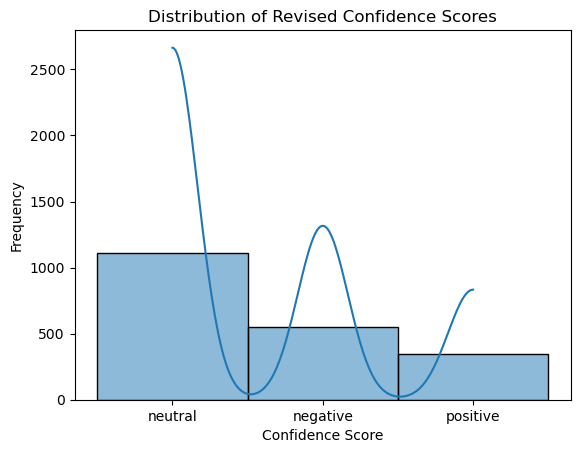

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("data_annotated.csv")
sns.histplot(data=df, x="pred_label_revised", bins=20, kde=True)
plt.title("Distribution of Revised Confidence Scores")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.show()


In [30]:
df[df["confidence_revised"] > 0.6]

,text,pred_label_revised,confidence_revised
770,"Sacombank đặt mục tiêu tăng trưởng lên đến 15% — Trên cơ sở được Đại hội đồng cổ đông thông qua cũng như nắm bắt các xu hướng tài chính sắp tới, Sacombank đặt kế hoạch năm 2025 tăng trưởng nhiều chỉ tiêu quan trọng từ 10 - 15%.",neutral,0.9
771,"Sau vụ lòng se điếu, đại biểu đề nghị 'nghề của thanh tra' là phải làm đột xuất — Dẫn vụ việc ""lòng se điếu"", Giám đốc Sở An toàn thực phẩm TPHCM Phạm Khánh Phong Lan cho biết, mới thông tin là sẽ cho kiểm tra thì truyền thông đã đăng tải rất nhiều, ""đi đến đâu cũng thông báo em hết lòng"", như thế sẽ rất khó.",neutral,0.9
772,"Giám đốc Sở GD-ĐT Hà Nội nói về việc chấm thi, công bố điểm thi lớp 10 — Các đề thi vào lớp 10 Hà Nội năm 2025, đặc biệt là đề môn Văn được đánh giá hay, xóa bỏ định hướng khuôn mẫu. Giám đốc Sở GD-ĐT Hà Nội cho hay việc chấm thi cũng sẽ đảm bảo công bằng giữa các thí sinh.",neutral,0.9
773,"Bộ trưởng Nội vụ giải đáp vướng mắc về chế độ cho lao động hợp đồng nghỉ việc — Bộ Nội vụ sẽ rà soát và bổ sung quy định về chế độ, chính sách với những trường hợp ký hợp đồng đúng quy định nhưng mức hưởng không được ưu đãi như quy định tại Nghị định 178.",neutral,0.9
774,"Lý do Hàn Quốc đột ngột phát tiền miễn phí cho mọi công dân — Nhà chức trách Hàn Quốc thông báo, nước này sẽ bắt đầu phát tiền mặt miễn phí cho mọi công dân vào ngày 21/7.",neutral,0.9
...,...,...,...
2006,"Đại gia nhà đất kín tiếng ở TPHCM lỗ hơn 600 tỷ, còn nợ 1.470 tỷ đồng trái phiếu — Doanh nghiệp địa ốc kín tiếng, có mối liên hệ với một số đại gia bất động sản đang ở trong tình hình tài chính khá yếu và thua lỗ kéo dài.",negative,1.0
2007,"Đề xuất doanh nghiệp nhà nước trả lương theo thị trường như tư nhân — Đề xuất cho phép doanh nghiệp nhà nước xây dựng cơ chế trả lương linh hoạt theo công việc, tùy thuộc vào nhu cầu thị trường được đưa ra tại hội nghị doanh nghiệp tiên phong chuyển đổi số.",positive,1.0
2008,"Số cán bộ, công chức cần tinh giản khi sáp nhập TPHCM, Bình Dương, Bà Rịa – Vũng Tàu — Sau khi sáp nhập TPHCM, Bình Dương và Bà Rịa – Vũng Tàu, TPHCM mới dự kiến có 168 phường, xã với 6.120 cán bộ, công chức và viên chức; dự kiến có 11.015 người dôi dư cần tinh giản trong 5 năm.",negative,1.0
2009,"Một tập đoàn quyết định về lương khởi điểm khiến hàng vạn sinh viên nức lòng — Tin vui lớn khiến hàng vạn sinh viên háo hức, khi CT Group công bố mức lương khởi điểm 20 triệu đồng/tháng cho sinh viên mới ra trường và tăng tiến lương theo hoạt động đổi mới sáng tạo sinh viên đảm nhiệm tại trường.",positive,1.0


In [31]:
from IPython.display import display
display(view[view["confidence_revised"] > 0.6])

,text,pred_label_revised,confidence_revised
770,"Sacombank đặt mục tiêu tăng trưởng lên đến 15% — Trên cơ sở được Đại hội đồng cổ đông thông qua cũng như nắm bắt các xu hướng tài chính sắp tới, Sacombank đặt kế hoạch năm 2025 tăng trưởng nhiều chỉ tiêu quan trọng từ 10 - 15%.",neutral,0.9
771,"Sau vụ lòng se điếu, đại biểu đề nghị 'nghề của thanh tra' là phải làm đột xuất — Dẫn vụ việc ""lòng se điếu"", Giám đốc Sở An toàn thực phẩm TPHCM Phạm Khánh Phong Lan cho biết, mới thông tin là sẽ cho kiểm tra thì truyền thông đã đăng tải rất nhiều, ""đi đến đâu cũng thông báo em hết lòng"", như thế sẽ rất khó.",neutral,0.9
772,"Giám đốc Sở GD-ĐT Hà Nội nói về việc chấm thi, công bố điểm thi lớp 10 — Các đề thi vào lớp 10 Hà Nội năm 2025, đặc biệt là đề môn Văn được đánh giá hay, xóa bỏ định hướng khuôn mẫu. Giám đốc Sở GD-ĐT Hà Nội cho hay việc chấm thi cũng sẽ đảm bảo công bằng giữa các thí sinh.",neutral,0.9
773,"Bộ trưởng Nội vụ giải đáp vướng mắc về chế độ cho lao động hợp đồng nghỉ việc — Bộ Nội vụ sẽ rà soát và bổ sung quy định về chế độ, chính sách với những trường hợp ký hợp đồng đúng quy định nhưng mức hưởng không được ưu đãi như quy định tại Nghị định 178.",neutral,0.9
774,"Lý do Hàn Quốc đột ngột phát tiền miễn phí cho mọi công dân — Nhà chức trách Hàn Quốc thông báo, nước này sẽ bắt đầu phát tiền mặt miễn phí cho mọi công dân vào ngày 21/7.",neutral,0.9
...,...,...,...
2006,"Đại gia nhà đất kín tiếng ở TPHCM lỗ hơn 600 tỷ, còn nợ 1.470 tỷ đồng trái phiếu — Doanh nghiệp địa ốc kín tiếng, có mối liên hệ với một số đại gia bất động sản đang ở trong tình hình tài chính khá yếu và thua lỗ kéo dài.",negative,1.0
2007,"Đề xuất doanh nghiệp nhà nước trả lương theo thị trường như tư nhân — Đề xuất cho phép doanh nghiệp nhà nước xây dựng cơ chế trả lương linh hoạt theo công việc, tùy thuộc vào nhu cầu thị trường được đưa ra tại hội nghị doanh nghiệp tiên phong chuyển đổi số.",positive,1.0
2008,"Số cán bộ, công chức cần tinh giản khi sáp nhập TPHCM, Bình Dương, Bà Rịa – Vũng Tàu — Sau khi sáp nhập TPHCM, Bình Dương và Bà Rịa – Vũng Tàu, TPHCM mới dự kiến có 168 phường, xã với 6.120 cán bộ, công chức và viên chức; dự kiến có 11.015 người dôi dư cần tinh giản trong 5 năm.",negative,1.0
2009,"Một tập đoàn quyết định về lương khởi điểm khiến hàng vạn sinh viên nức lòng — Tin vui lớn khiến hàng vạn sinh viên háo hức, khi CT Group công bố mức lương khởi điểm 20 triệu đồng/tháng cho sinh viên mới ra trường và tăng tiến lương theo hoạt động đổi mới sáng tạo sinh viên đảm nhiệm tại trường.",positive,1.0


# Chia tập dữ liệu

In [1]:
# Giả sử `df` đã tồn tại (pandas DataFrame)
# Data1: chỉ số 0..1005 (inclusive) -> dùng .iloc[0:1006]
# Data2: phần còn lại -> .iloc[1006:]
import pandas as pd
df = pd.read_csv("data_annotated.csv")
data1 = df.iloc[0:1006].copy()
data2 = df.iloc[1006:].copy()

data1.to_csv("Trang_Truong.csv", index=False, encoding="utf-8-sig")
data2.to_csv("Thanh_Thanh.csv", index=False, encoding="utf-8-sig")

print(f"Đã lưu data1.csv ({data1.shape[0]} hàng) và data2.csv ({data2.shape[0]} hàng).")


Đã lưu data1.csv (1006 hàng) và data2.csv (1005 hàng).
